In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data.csv")

df.head()

,Employee_ID,Name,Age,Department,Salary,Joining_Date
0,101,Aman,24.0,IT,45000.0,2023-01-15
1,102,Riya,27.0,HR,52000.0,NaN
2,103,Karan,29.0,Sales,48000.0,2021-06-10
3,104,Neha,25.0,IT,53500.0,2023-03-20
4,105,Rahul,28.0,Finance,61000.0,2020-11-05


# Mean, Median, Standard Deviation & Percentiles 

In [2]:
# Calculating basic statistics for Salary

mean_salary = df["Salary"].mean()
median_salary = df["Salary"].median()
standard_deviation = df["Salary"].std()

q25 = df["Salary"].quantile(0.25)
q50 = df["Salary"].quantile(0.50)
q75 = df["Salary"].quantile(0.75)

print("Mean Salary:", mean_salary)
print("Median Salary:", median_salary)
print("Standard Deviation:", standard_deviation)
print("25th Percentile:", q25)
print("50th Percentile:", q50)
print("75th Percentile:", q75)

Mean Salary: 54720.0
Median Salary: 53500.0
Standard Deviation: 8361.718324204261
25th Percentile: 49500.0
50th Percentile: 53500.0
75th Percentile: 58000.0


## Plot distribution , identify skewness and outliers

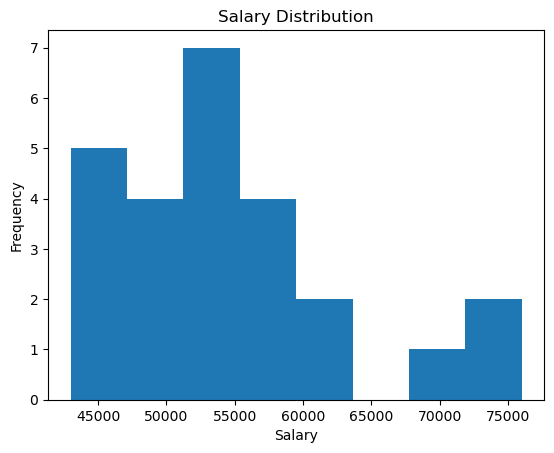

In [3]:
# Histogram of salary distribution
import matplotlib.pyplot as plt

plt.hist(df["Salary"], bins=8)

plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")

plt.show()

In [4]:
# Calculating skewness of Salary

skewness = df["Salary"].skew()

print("Skewness:", skewness)

Skewness: 0.9733366578135031


# Identify outliers


In [5]:
# Calculating Q1, Q3 and IQR

q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)

iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

Q1: 49500.0
Q3: 58000.0
IQR: 8500.0


In [6]:
# Calculating outlier boundaries

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 36750.0
Upper Bound: 70750.0


In [7]:
# Identifying salary outliers

outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

print("Salary Outliers:")
print(outliers[["Employee_ID", "Name", "Salary"]])

Salary Outliers:
    Employee_ID    Name   Salary
8           109  Vikram  72000.0
20          121  Manish  76000.0


# Correlation Matrix + Strongest Pair

In [8]:
# Calculating correlation between Age and Salary

correlation_matrix = df[["Age", "Salary"]].corr()

print(correlation_matrix)

             Age    Salary
Age     1.000000  0.718608
Salary  0.718608  1.000000


In [10]:
# Strongest Pair
correlation = df["Age"].corr(df["Salary"])

print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.7186077880437344


# Two-Group Hypothesis Testing

## creating a group

In [11]:
from scipy.stats import ttest_ind

hr_salary = df[df["Department"] == "HR"]["Salary"]
sales_salary = df[df["Department"] == "Sales"]["Salary"]

print("HR Salaries:")
print(hr_salary)

print("\nSales Salaries:")
print(sales_salary)

HR Salaries:
1     52000.0
5     58000.0
9     43000.0
13    49500.0
17    57000.0
21    59000.0
Name: Salary, dtype: float64

Sales Salaries:
2     48000.0
7     55000.0
10    53500.0
14    46000.0
18    63000.0
22    50000.0
24    56000.0
Name: Salary, dtype: float64


## Independent t-test 

In [12]:
# Performing independent two-sample t-test

t_statistic, p_value = ttest_ind(hr_salary, sales_salary)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 0.0036102622952977376
P-value: 0.9971840760423156


In [13]:
# Interpreting the p-value

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average salaries.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average salaries.")

Fail to reject the null hypothesis.
There is no statistically significant difference in average salaries.


In [14]:
# Interpretation:
# The p-value is 0.9972, which is greater than the significance level of 0.05.
# Therefore, we fail to reject the null hypothesis.
# There is no statistically significant difference between the average
# salaries of HR and Sales employees in this dataset.